# Bouncing Ball Backend Validation

This notebook compares the three impact-capable bouncing-ball backends currently available in the repo:

- `backward_euler` + impulse contact
- `sdirk2` + impulse contact
- `rattle`

We look at two regimes:

1. Persistent contact
2. Free-fall bounce with restitution

For each regime we display:

- a summary table
- state and contact-signal plots
- a convergence sweep over multiple step counts


In [13]:
import importlib
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
EXAMPLES = ROOT / "examples"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(EXAMPLES) not in sys.path:
    sys.path.insert(0, str(EXAMPLES))

import bouncing_ball_backend_helpers as _bb_helpers
_bb_helpers = importlib.reload(_bb_helpers)

convergence_sweep_dataframe = _bb_helpers.convergence_sweep_dataframe
make_free_fall_case = _bb_helpers.make_free_fall_case
make_persistent_contact_case = _bb_helpers.make_persistent_contact_case
results_summary_dataframe = _bb_helpers.results_summary_dataframe
run_case_bundle = _bb_helpers.run_case_bundle


def plot_case_results(results, title):
    first = next(iter(results.values()))
    t_ref = np.asarray(first["times"], dtype=float)
    q_ref = np.asarray(first["q_y_ref"], dtype=float)
    v_ref = np.asarray(first["v_y_ref"], dtype=float)

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex="col")

    ax[0, 0].plot(t_ref, q_ref, "k--", linewidth=1.5, label="reference")
    for result in results.values():
        t = np.asarray(result["times"], dtype=float)
        q = np.asarray(result["q_y"], dtype=float)
        ax[0, 0].plot(t, q, label=result["backend_label"])
    ax[0, 0].set_ylabel("height q_y")
    ax[0, 0].set_title("Vertical Position")
    ax[0, 0].legend()

    ax[0, 1].plot(t_ref, v_ref, "k--", linewidth=1.5, label="reference")
    for result in results.values():
        t = np.asarray(result["times"], dtype=float)
        v = np.asarray(result["v_y"], dtype=float)
        ax[0, 1].plot(t, v, label=result["backend_label"])
    ax[0, 1].set_ylabel("velocity v_y")
    ax[0, 1].set_title("Vertical Velocity")
    ax[0, 1].legend()

    for result in results.values():
        t = np.asarray(result["times"], dtype=float)
        q = np.asarray(result["q_y"], dtype=float)
        q_exact = np.asarray(result["q_y_ref"], dtype=float)
        ax[1, 0].plot(t, q - q_exact, label=result["backend_label"])
    ax[1, 0].set_xlabel("time")
    ax[1, 0].set_ylabel("q_y - q_ref")
    ax[1, 0].set_title("Position Error")
    ax[1, 0].legend()

    for result in results.values():
        t = np.asarray(result["times"], dtype=float)
        r = np.asarray(result["r_n"], dtype=float)
        ax[1, 1].plot(t, r, label=result["backend_label"])
    ax[1, 1].set_xlabel("time")
    ax[1, 1].set_ylabel("normal reaction / impulse density proxy")
    ax[1, 1].set_title("Normal Contact Signal")
    ax[1, 1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    return fig, ax


def plot_convergence(df, title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
    metrics = [
        ("max_abs_q_error", "max |q error|"),
        ("impact_time_error", "impact time error"),
        ("wall_time_s", "wall time [s]"),
    ]
    for axis, (metric, metric_title) in zip(ax, metrics, strict=True):
        for backend_label, group in df.groupby("backend_label", sort=False):
            g = group.sort_values("dt", ascending=False)
            axis.loglog(g["dt"], g[metric], marker="o", label=backend_label)
        axis.set_xlabel("dt")
        axis.set_title(metric_title)
        axis.grid(True, which="both", alpha=0.3)
        axis.legend()
    fig.suptitle(title)
    fig.tight_layout()
    return fig, ax


In [14]:
SOLVERS = ("backward_euler", "sdirk2", "rattle")

N_STEPS = 1000
SWEEP_STEPS = (500,)
SOLVER_MAX_ITER = 200
T_END = 10.0
RESTITUTION = 1.0
HEIGHT0 = 1.0
VY0 = 0.0

display(
    pd.DataFrame(
        [
            {
                "solvers": ", ".join(SOLVERS),
                "n_steps": N_STEPS,
                "sweep_steps": str(SWEEP_STEPS),
                "solver_max_iter": SOLVER_MAX_ITER,
                "t_end": T_END,
                "restitution": RESTITUTION,
                "height0": HEIGHT0,
                "vy0": VY0,
            }
        ]
    )
)


,solvers,n_steps,sweep_steps,solver_max_iter,t_end,restitution,height0,vy0
0,"backward_euler, rattle",1000,"(500,)",200,10.0,1.0,1.0,0.0


## Persistent Contact

This case starts already in contact with zero restitution and should be easy for all three methods. It is mainly useful for checking cost and long-time contact consistency.

### Persistent Contact Summary

,backend_label,success,mean_step_iterations,wall_time_s,max_abs_q_error,max_abs_v_error,max_penetration,final_qy,final_vy,final_rn
0,Backward Euler + SOC,True,1.002997,0.154476,1.466822e-41,2.997671e-28,1.466822e-41,-1.466822e-41,-2.997671e-28,1.655476e-12
1,RATTLE (Lobatto IIIA-IIIB),True,2.004000,0.039977,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.810000e+00


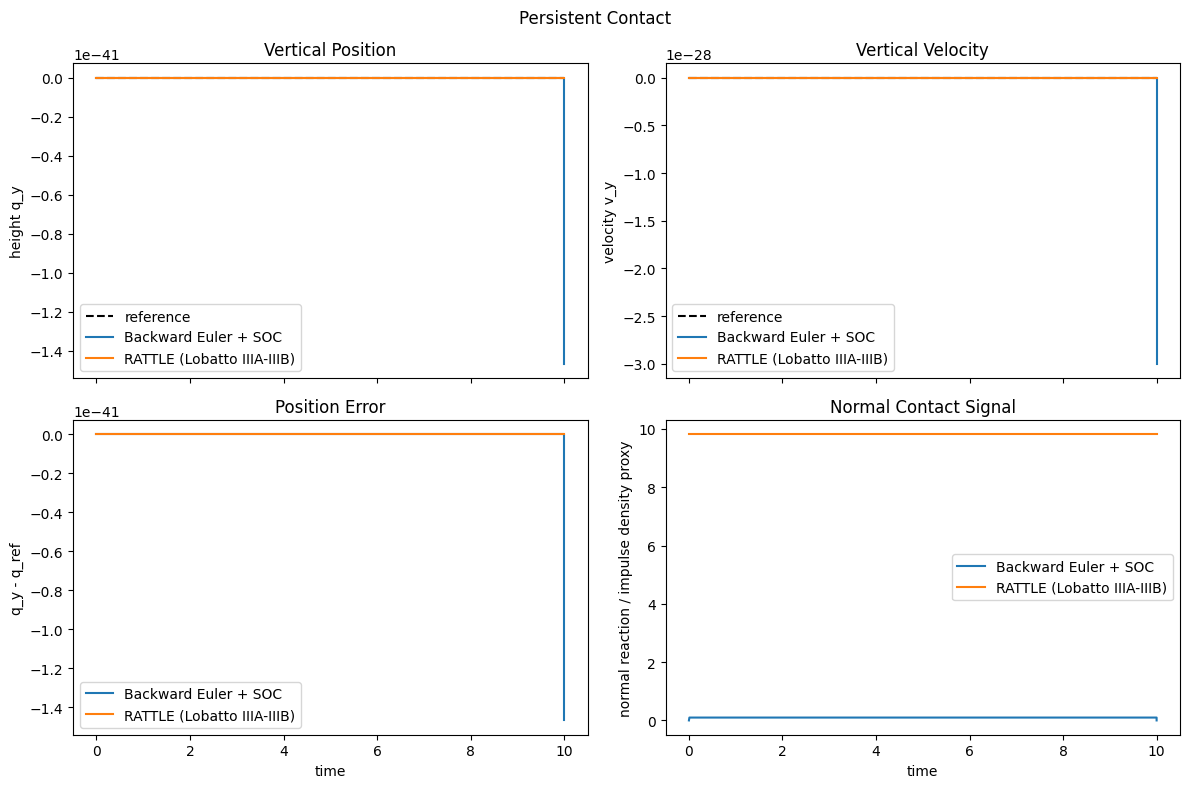

In [15]:
persistent_case = make_persistent_contact_case(t_end=T_END)
persistent_results = run_case_bundle(
    persistent_case,
    solvers=SOLVERS,
    n_steps=N_STEPS,
    solver_max_iter=SOLVER_MAX_ITER,
)

persistent_summary = results_summary_dataframe(persistent_results)
display(Markdown("### Persistent Contact Summary"))
display(
    persistent_summary[
        [
            "backend_label",
            "success",
            "mean_step_iterations",
            "wall_time_s",
            "max_abs_q_error",
            "max_abs_v_error",
            "max_penetration",
            "final_qy",
            "final_vy",
            "final_rn",
        ]
    ]
)

fig, ax = plot_case_results(persistent_results, "Persistent Contact")
plt.show()


### Persistent Contact Convergence Sweep

,backend,backend_label,n_steps,dt,success,mean_step_iterations,wall_time_s,max_abs_q_error,max_abs_v_error,impact_time_error,rebound_apex_error,max_penetration
0,backward_euler,Backward Euler + SOC,500,0.02,True,1.007984,0.065228,0.0,0.0,0.02,0.0,0.0
1,rattle,RATTLE (Lobatto IIIA-IIIB),500,0.02,True,2.008000,0.014092,0.0,0.0,0.00,0.0,0.0


/tmp/ipykernel_50824/2811022916.py:94: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.tight_layout()


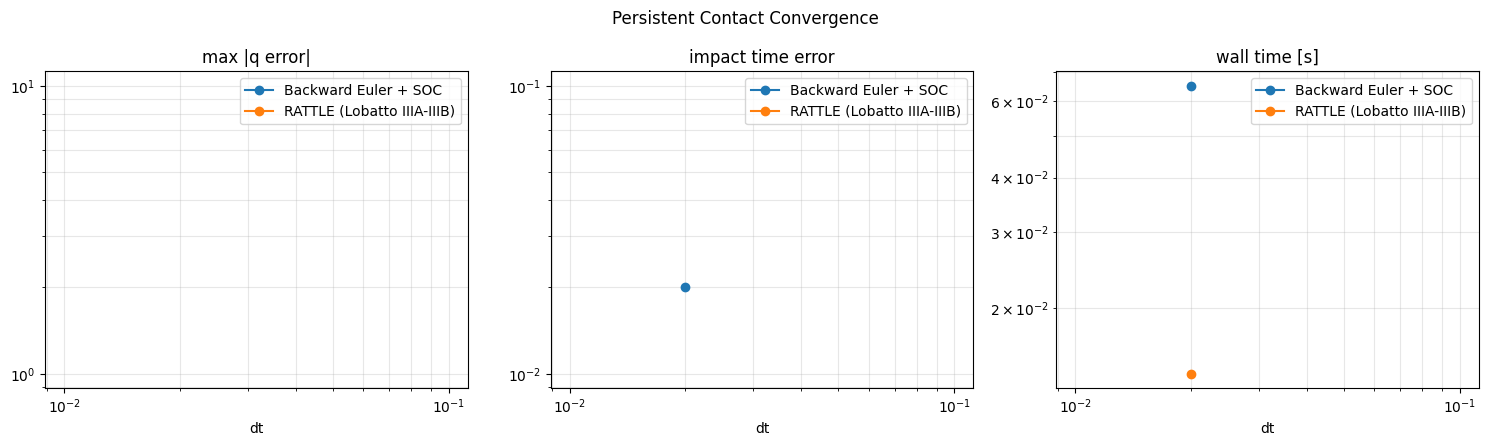

In [16]:
persistent_conv = convergence_sweep_dataframe(
    persistent_case,
    solvers=SOLVERS,
    step_counts=SWEEP_STEPS,
    solver_max_iter=SOLVER_MAX_ITER,
)

display(Markdown("### Persistent Contact Convergence Sweep"))
display(persistent_conv)

fig, ax = plot_convergence(persistent_conv, "Persistent Contact Convergence")
plt.show()


## Free-Fall Bounce

This case drops the ball from height `HEIGHT0` with restitution `RESTITUTION`. Here the event timing error becomes important, so this is a better test of real impact handling.

### Free-Fall Bounce Summary

,backend_label,success,mean_step_iterations,wall_time_s,max_abs_q_error,max_abs_v_error,impact_time_error,rebound_apex_error,max_penetration,final_qy,final_vy,final_rn
0,Backward Euler + SOC,True,2.79021,0.549686,0.538128,8.730900,0.001524,9.992007e-16,0.000000e+00,0.773389,-2.0601,0.0
1,RATTLE (Lobatto IIIA-IIIB),True,4.04000,0.043950,0.763617,8.790688,0.008476,6.737500e-03,6.938894e-18,0.435564,-3.0411,0.0


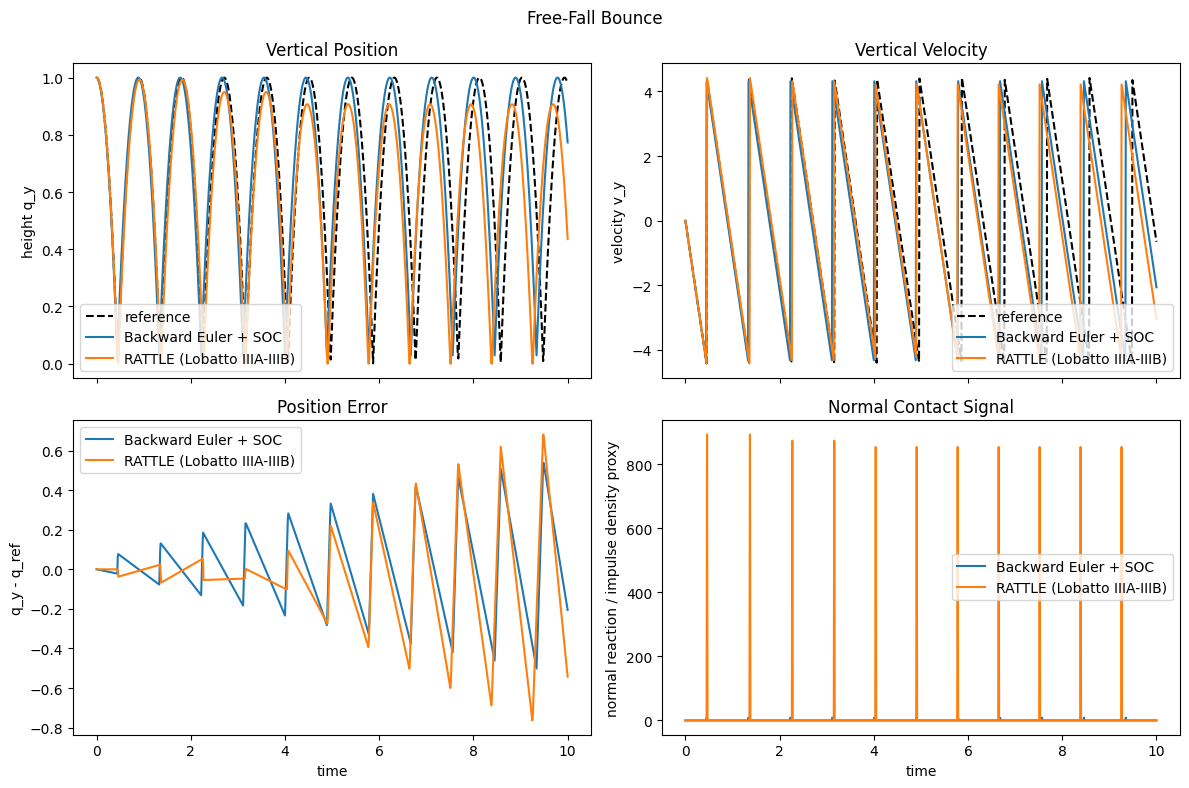

In [17]:
free_fall_case = make_free_fall_case(
    t_end=T_END,
    restitution=RESTITUTION,
    height0=HEIGHT0,
    vy0=VY0,
)
free_fall_results = run_case_bundle(
    free_fall_case,
    solvers=SOLVERS,
    n_steps=N_STEPS,
    solver_max_iter=SOLVER_MAX_ITER,
)

free_fall_summary = results_summary_dataframe(free_fall_results)
display(Markdown("### Free-Fall Bounce Summary"))
display(
    free_fall_summary[
        [
            "backend_label",
            "success",
            "mean_step_iterations",
            "wall_time_s",
            "max_abs_q_error",
            "max_abs_v_error",
            "impact_time_error",
            "rebound_apex_error",
            "max_penetration",
            "final_qy",
            "final_vy",
            "final_rn",
        ]
    ]
)

fig, ax = plot_case_results(free_fall_results, "Free-Fall Bounce")
plt.show()


### Free-Fall Bounce Convergence Sweep

,backend,backend_label,n_steps,dt,success,mean_step_iterations,wall_time_s,max_abs_q_error,max_abs_v_error,impact_time_error,rebound_apex_error,max_penetration
0,backward_euler,Backward Euler + SOC,500,0.02,True,2.790419,0.253265,0.176284,8.739318,0.008476,0.000000,0.000000e+00
1,rattle,RATTLE (Lobatto IIIA-IIIB),500,0.02,True,4.080000,0.020544,0.981550,8.406706,0.008476,0.050392,7.771561e-18


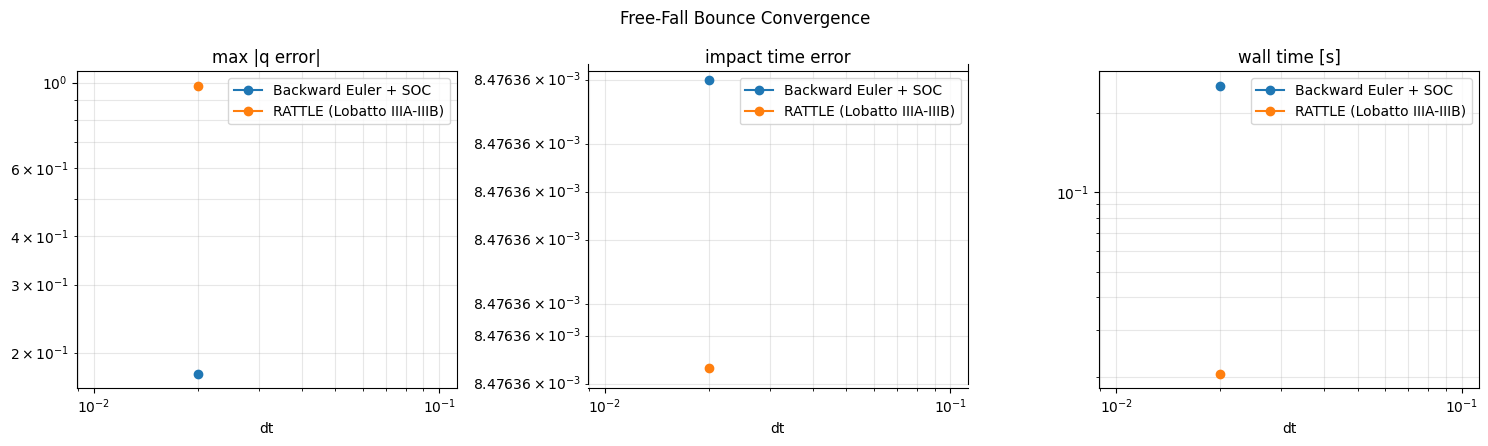

In [18]:
free_fall_conv = convergence_sweep_dataframe(
    free_fall_case,
    solvers=SOLVERS,
    step_counts=SWEEP_STEPS,
    solver_max_iter=SOLVER_MAX_ITER,
)

display(Markdown("### Free-Fall Bounce Convergence Sweep"))
display(free_fall_conv)

fig, ax = plot_convergence(free_fall_conv, "Free-Fall Bounce Convergence")
plt.show()
